# Anomalie di temperatura nelle Isole Britanniche (Regno Unito + Irlanda) e confronto con l'AMO Index

Questo notebook ricostruisce la serie storica delle anomalie di temperatura delle Isole Britanniche a partire dai dati di stazione **CRUTEM 4.6.0.0** e la confronta con l'**AMO Index** (Atlantic Multidecadal Oscillation) calcolato dai dati osservati di temperatura superficiale del mare **HadISST**.


In [1]:
# Libraries
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

from datetime import datetime
from tqdm import tqdm
import datetime as dtm

import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy.feature as cf

import xarray as xr

from scipy import stats

# Dati CRUTEM

### Struttura del file di una stazione 

Il file è un file di testo ASCII e si compone di due sezioni principali:

### Intestazione (Header)

Contiene i metadati della stazione, uno per riga, nel formato `Chiave`:

* `Number=` : Identificatore univoco della stazione, spesso il numero assegnato dall'Organizzazione Meteorologica Mondiale (WMO).
* `Name=` : Nome della stazione.
* `Country=` : Paese di appartenenza.
* `Lat=` : Latitudine (gradi decimali, positivi per Nord).
* `Long=` : Longitudine. **Attenzione**: nei file CRUTEM4, i valori negativi indicano **Est** (corretto dopo).
* `Height=` : Altitudine della stazione in metri.
* `Start year=` / `End year=` : Primo e ultimo anno della serie temporale.
* `First Good year=` : Anno a partire dal quale i dati sono considerati affidabili.
* `Normals=` : 12 valori che rappresentano le temperature medie mensili (da Gennaio a Dicembre) per un periodo di riferimento (es. 1961-1990).
* `Standard deviations=` : 12 valori con le deviazioni standard mensili.

### Osservazioni (Observations)

Dopo l'intestazione, i dati iniziano con la riga `Obs:`. Ogni riga successiva rappresenta un anno e contiene **24 colonne** numeriche:

* **Colonna 1:** L'anno.
* **Colonne 2-13:** Le 12 temperature medie mensili (da Gennaio a Dicembre) in gradi Celsius.
    * **Valore mancante:** `-99.0` indica un dato non disponibile.
* **Colonne 14-25:** Codici che indicano la **fonte dei dati** per ogni mese (es. `501` per un aggiornamento del database del 2012).

**Cosa fa:** elenca tutti i file delle stazioni meteorologiche contenuti nell'archivio CRUTEM e conta quante stazioni sono disponibili. **Perché:** ogni file ASCII contiene i metadati e la serie mensile di una stazione; serve la lista completa per poterli leggere uno a uno.

In [2]:
DATA_DIR = r'C:\Users\kekko\Downloads\Python\Lab of Geo\Data\CRUTEM.4.6.0.0.station_files'

# per capire come e' costituito il dataset
flist = [os.path.join(path, name)
         for path, subdirs, files in os.walk(DATA_DIR)
         for name in files]

for i in range(0, 5):
    print(flist[i])

# exclude first 2 items, not relevant (es. file Index)
flist = flist[2:]

print('\n', flist[0:5])
nst = len(flist)
print('\n > Number of stations = ', nst)  # si hanno piu' di 10k stazioni

C:\Users\kekko\Downloads\Python\Lab of Geo\Data\CRUTEM.4.6.0.0.station_files\Index
C:\Users\kekko\Downloads\Python\Lab of Geo\Data\CRUTEM.4.6.0.0.station_files\01\010010
C:\Users\kekko\Downloads\Python\Lab of Geo\Data\CRUTEM.4.6.0.0.station_files\01\010030
C:\Users\kekko\Downloads\Python\Lab of Geo\Data\CRUTEM.4.6.0.0.station_files\01\010050
C:\Users\kekko\Downloads\Python\Lab of Geo\Data\CRUTEM.4.6.0.0.station_files\01\010070

 ['C:\\Users\\kekko\\Downloads\\Python\\Lab of Geo\\Data\\CRUTEM.4.6.0.0.station_files\\01\\010030', 'C:\\Users\\kekko\\Downloads\\Python\\Lab of Geo\\Data\\CRUTEM.4.6.0.0.station_files\\01\\010050', 'C:\\Users\\kekko\\Downloads\\Python\\Lab of Geo\\Data\\CRUTEM.4.6.0.0.station_files\\01\\010070', 'C:\\Users\\kekko\\Downloads\\Python\\Lab of Geo\\Data\\CRUTEM.4.6.0.0.station_files\\01\\010080', 'C:\\Users\\kekko\\Downloads\\Python\\Lab of Geo\\Data\\CRUTEM.4.6.0.0.station_files\\01\\010100']

 > Number of stations =  10295


Risultato: l'archivio contiene oltre 10.000 stazioni in tutto il mondo: da qui verranno poi selezionate solo quelle delle Isole Britanniche.

## Stazioni Irlandesi e del Regno Unito

**Cosa fa / perché:** l'analisi si compone dalle stazioni del Regno Unito e dell'Irlanda. Le Isole Britanniche sono un'area climaticamente omogenea (clima oceanico temperato), quindi trattarle insieme è coerente dal punto di vista geografico e statistico.

La cella diagnostica seguente campiona un sottoinsieme di file e individua le stringhe esatte del campo paese, sia per il Regno Unito sia per l'Irlanda, da usare nel filtro della cella di lettura dati.

In [3]:
# Il campo 'Country' nei file CRUTEM non e' standardizzato in modo univoco:
# a seconda della versione puo' comparire come 'UK', 'UNITED KINGDOM', 'IRELAND',
# 'IRISH REPUBLIC', ecc. Qui si campiona un sottoinsieme di file per individuare
# le stringhe esatte da usare nel filtro della cella successiva.
from concurrent.futures import ThreadPoolExecutor

def estrai_paese(filein):
    """Estrae il campo Country dal singolo file (eseguita in parallelo)."""
    try:
        with open(filein, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                if line.startswith('Country'):
                    return line.split('=', 1)[1].strip()
    except Exception:
        pass  # Ignora file corrotti o non accessibili
    return None

campione = flist[:3000]
with ThreadPoolExecutor() as executor:
    risultati = executor.map(estrai_paese, campione)

found_countries = {res for res in risultati if res}

uk_keywords = ('UK', 'KINGDOM', 'BRITAIN')
ie_keywords = ('IRELAND', 'EIRE', 'IRISH')
uk_like = sorted(c for c in found_countries if any(w in c.upper() for w in uk_keywords))
ie_like = sorted(c for c in found_countries if any(w in c.upper() for w in ie_keywords))

print('Possibili varianti trovate per UK:     ', uk_like)
print('Possibili varianti trovate per Irlanda:', ie_like)
print('\n> Copia le stringhe esatte nella variabile TARGET_COUNTRIES nella cella successiva.')

Possibili varianti trovate per UK:      ['UK']
Possibili varianti trovate per Irlanda: ['IRELAND']

> Copia le stringhe esatte nella variabile TARGET_COUNTRIES nella cella successiva.


Risultato: la diagnostica conferma le stringhe presenti nel dataset (`UK` e `IRELAND`), che vengono usate nell'insieme `TARGET_COUNTRIES` del filtro.

## Strutture dati per metadati e serie

**Cosa fa:** crea il DataFrame vuoto dei metadati (ID, nome, paese, quota, lat, lon). Gli ID stazione fungono da identificatore univoco.

In [4]:
# Define df to store metadata.
# Station IDs will be used as unique identifiers for both dataframes.
metadata0 = pd.DataFrame(columns=[
    'ID', 
    'stname', 
    'country', 
    'elev', 
    'lat', 
    'lon'])

## Asse temporale comune e periodo di riferimento

**Cosa fa:** definisce un asse temporale mensile comune (1850–2018) su cui allineare tutte le stazioni e fissa il periodo di riferimento per il calcolo delle normali climatiche. **Perché:** stazioni diverse coprono intervalli diversi; un asse comune permette di combinarle e confrontarle correttamente.

### Periodo di riferimento per le normals

Qui si fissa **un solo** periodo di riferimento nelle variabili `yref0`/`yref1` e, nella cella delle normali, lo slice viene costruito **da queste variabili**

In [5]:
# define a common time axis
taxis = pd.date_range('1850-01', '2019-01', freq='ME')
nmonths = len(taxis)
nyears = nmonths / 12

# Define df to store data (temperature time series).
data0 = pd.DataFrame({'time': taxis}).set_index('time')

# Periodo di riferimento per il calcolo dell'anomalia (1951-2010)
yref0 = 1951
yref1 = 2010

## Lettura e filtraggio delle stazioni

**Cosa fa:** scorre tutti i file, ne estrae metadati e serie, e applica i filtri: paese in `{'UK','IRELAND'}`, normali valide e almeno 30 anni di dati. **Perché:** si selezionano solo stazioni delle Isole Britanniche con serie sufficientemente lunghe per essere rappresentative del clima locale.

In [6]:
metadata_list = []
data_series_list = []
nodatacount = tooshortcount = outsidecount = 0

TARGET_COUNTRIES = {'UK', 'IRELAND'}  # stringhe confermate dalla cella diagnostica

for filein in tqdm(flist[:nst]):
    with open(filein, 'r') as f:
        lines = f.readlines()

    # Estrazione metadati e individuazione inizio osservazioni
    header = {}
    obs_index = -1
    for i, line in enumerate(lines):
        if '=' in line:
            k, v = line.split('=', 1)
            header[k.strip()] = v.strip()
        if 'Obs:' in line:
            obs_index = i + 1
            break

    # 1. Filtro esistenza dati
    if obs_index == -1 or len(lines) <= obs_index:
        nodatacount += 1
        continue

    # 2. Filtro Country e Normals
    if header.get('Country', '').strip().upper() not in TARGET_COUNTRIES:
        continue
    if '-99.0' in header.get('Normals', ''):
        outsidecount += 1
        continue

    # Lettura dati numerici
    try:
        raw_data = np.loadtxt(lines[obs_index:], dtype='f4')
        if raw_data.ndim == 1:
            raw_data = raw_data.reshape(1, -1)
    except Exception:
        continue

    # 3. Filtro durata (anni)
    nyr = len(raw_data)
    if nyr < 30:
        tooshortcount += 1
        continue

    # Salvataggio Metadati
    st_id = filein[-6:]
    metadata_list.append({
        'ID': st_id, 'nome': header.get('Name'), 'paese': header.get('Country'),
        'altezza': float(header.get('Height', 0)), 'lat': float(header.get('Lat', 0)),
        'lon': float(header.get('Long', 0))
    })

    # Preparazione serie temporale (colonne 1..12 = mesi; colonna 0 = anno)
    values = raw_data[:, 1:13].flatten()
    ti0 = datetime(int(raw_data[0, 0]), 1, 1)
    stime = pd.date_range(ti0, periods=len(values), freq='ME')
    data_series_list.append(pd.Series(values, index=stime, name=st_id))

# Creazione DataFrame finali
metadata0 = pd.DataFrame(metadata_list)
data0 = pd.concat(data_series_list, axis=1)

100%|██████████| 10295/10295 [01:02<00:00, 163.73it/s]


Risultato: al termine del loop si ottengono i DataFrame `metadata0` (metadati) e `data0` (serie mensili allineate).

### Riepilogo del filtraggio

In [7]:
print(f'Skipped - no data:     {nodatacount}')
print(f'Skipped - too short:   {tooshortcount}')
print(f'Skipped - outside ref: {outsidecount}')
print(f'Stations retained:     {len(metadata0)}')

Skipped - no data:     1
Skipped - too short:   1
Skipped - outside ref: 11
Stations retained:     64


Risultato: l'inclusione dell'Irlanda porta a **64 stazioni** mantenute

### Metadati delle stazioni selezionate


In [8]:
print('\nMetadata:')
print(metadata0)


Metadata:
        ID               nome    paese  altezza   lat   lon
0   030050            LERWICK       UK     82.0  60.1   1.2
1   030170           KIRKWALL       UK     26.0  59.0   2.9
2   030260          STORNOWAY       UK     13.0  58.2   6.3
3   030680      GORDON CASTLE       UK     32.0  57.6   3.1
4   030750       WICK AIRPORT       UK     36.0  58.5   3.1
..     ...                ...      ...      ...   ...   ...
59  039710       MULLINGAR II  IRELAND    104.0  53.5   7.4
60  039740             CLONES  IRELAND     89.0  54.2   7.2
61  039760          BELMULLET  IRELAND      9.0  54.2  10.0
62  039800         MALIN HEAD  IRELAND     20.0  55.4   7.3
63  039801  GLENTIES HATCHERY  IRELAND     44.0  54.8   8.3

[64 rows x 6 columns]


### Correzione della longitudine

**Cosa fa:** inverte il segno della longitudine. **Perché:** nei file CRUTEM la longitudine è memorizzata come positiva verso ovest; per la cartografia standard (est positivo) va invertita.

In [9]:
# correzione della longitudine (CRUTEM: positiva verso ovest -> est positivo)
metadata0.lon = -metadata0.lon

### Posizione delle stazioni

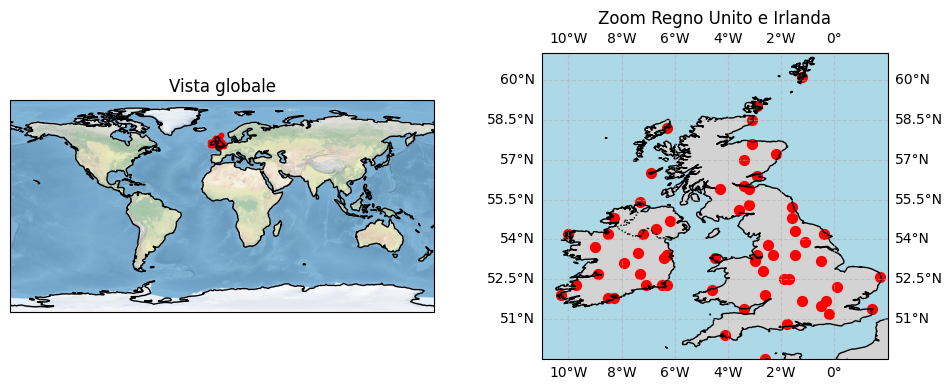

In [10]:
lon, lat = metadata0.lon, metadata0.lat
pc = ccrs.PlateCarree()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), subplot_kw=dict(projection=pc))

ax1.set_title('Vista globale')
ax1.stock_img()
ax1.coastlines()

ax2.set_title('Zoom Regno Unito e Irlanda')
ax2.set_extent([-11, 2, 49.5, 61], crs=pc)
ax2.coastlines(resolution='10m')
for feat, kw in [(cfeature.BORDERS, dict(linestyle=':')),
                 (cfeature.LAND, dict(facecolor='lightgray')),
                 (cfeature.OCEAN, dict(facecolor='lightblue'))]:
    ax2.add_feature(feat, **kw)
ax2.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

for ax, s in [(ax1, 10), (ax2, 50)]:
    ax.scatter(lon, lat, color='r', s=s, transform=pc)

plt.tight_layout()
plt.show()

### Pulizia dei valori mancanti

**Cosa fa:** sostituisce il valore convenzionale `-99.0` con `NaN`.

In [11]:
# Sostituisce i -99 con NaN in tutto il DataFrame
data0 = data0.replace(-99.0, np.nan)

## Normali climatiche e anomalie

**Cosa fa:** calcola, per ogni stazione e per ogni mese-calendario, la normale climatica sul periodo di riferimento, poi sottrae a ogni mese la sua normale per ottenere le anomalie. **Perché:** le anomalie rimuovono il ciclo stagionale e rendono confrontabili tra loro stazioni con clima medio diverso.

Una **normale climatica** (chiamato anche climatologia) è un valore di riferimento calcolata su un periodo di riferimento, relativo a un preciso intervallo temporale.

L'utilizzo di una normale è essenziale per il calcolo delle anomalie: sottraendo questo valore dai dati osservati, si elimina il ciclo stagionale, rendendo confrontabili serie storiche diverse.

Un'**anomalia** è la differenza tra un valore osservato in un certo mese e la normale di quel mese per quella stazione.

> **Esempio pratico: Calcolo dell'anomalia (Lerwick, Gennaio 2000)**
>
> * **Temperatura osservata** (Gennaio 2000): `5.2 °C`
> * **Normale climatica** (media 1951–2010): `3.8 °C`
> 
> **Anomalia** = `5.2 °C` - `3.8 °C` = `+1.4 °C`
>
> Questo significa che il mese di gennaio 2000 è stato di `1.4 °C` più caldo rispetto alla normale climatica di riferimento per la stazione di Lerwick.

In [12]:
# Normali sul periodo di riferimento 
ref = data0.loc[f'{yref0}':f'{yref1}']
normali = ref.groupby(ref.index.month).mean()   # media per mese-calendario, per stazione

# Anomalie: sottrae a ogni mese la normale del mese corrispondente
data_anom = data0.copy()
for m in range(1, 13):
    mask = data_anom.index.month == m
    data_anom.loc[mask] = data_anom.loc[mask].sub(normali.loc[m], axis=1)

print('Periodo di riferimento usato:', yref0, '-', yref1)
print('Shape anomalie (mesi x stazioni):', data_anom.shape)

Periodo di riferimento usato: 1951 - 2010
Shape anomalie (mesi x stazioni): (2664, 64)


Risultato: `data_anom` contiene le anomalie mensili (°C) per stazione, già prive del ciclo stagionale e confrontabili tra loro.

In [13]:
# Visualizzazione anomalie dop il 1950, primi 5 mesi
data_anom.loc['1951':].head()

,030050,030170,030260,030680,030750,030910,031000,031400,031540,031600,...,039670,039680,039690,039700,039701,039710,039740,039760,039800,039801
1951-01-31,-0.371667,-0.725000,-1.093333,-0.580,-0.458333,-1.393333,-0.730000,-0.075000,-0.107500,-0.877551,...,NaN,-0.047500,-0.660000,-0.566102,NaN,-0.626667,-0.646552,NaN,-0.890000,NaN
1951-02-28,-0.266667,-0.421667,-1.283333,-0.612,-0.330000,-0.773333,-1.188333,-0.546429,-0.422500,-0.851020,...,NaN,-1.045000,-1.791667,-1.612281,NaN,-1.338333,-1.770689,NaN,-1.588333,NaN
1951-03-31,-1.958333,-1.665000,-1.516666,-1.896,-1.440000,-1.986667,-1.560000,-1.921429,-1.917500,-2.212245,...,NaN,-1.430000,-1.793334,-1.743333,NaN,-1.660000,-1.648275,NaN,-1.865000,NaN
1951-04-30,-1.800000,-1.766667,-2.140000,-2.188,-1.766667,-2.175000,-1.723333,-1.610714,-1.900000,-1.579592,...,NaN,-1.150000,-1.664999,-1.562069,NaN,-1.700000,-1.854386,NaN,-1.906666,NaN
1951-05-31,-0.836667,-0.803333,-0.611667,-1.428,-1.081666,-2.068333,-0.520000,-1.185715,-1.290001,-2.110204,...,NaN,-1.337501,-1.379999,-1.023729,NaN,-1.361667,-1.328070,NaN,-1.908333,NaN


## Serie regionale unica

La griglia 10°×10° della versione precedente produceva celle con pochissime stazioni quindi serie rumorose e poco campionate. Poiché le Isole Britanniche sono un'unica regione climatica omogenea, le trattiamo come **una sola serie**: si media direttamente su tutte le stazioni. 

1. **Soglia minima di stazioni per mese** (`MIN_STAZ`): nei mesi con pochissime stazioni attive (soprattutto a inizio serie) la media è instabile, quindi viene messa a `NaN`.
2. **Media annuale solo su anni quasi completi** (`MIN_MESI`): si calcola la media annua solo se l'anno ha abbastanza mesi validi, per evitare il bias stagionale di un anno coperto solo, ad esempio, dai mesi estivi.

In [14]:
MIN_STAZ = 5    # stazioni minime per accettare la media di un mese
MIN_MESI = 10   # mesi validi minimi per accettare la media di un anno

# media mensile regionale solo dove ci sono abbastanza stazioni
conteggio_staz = data_anom.notna().sum(axis=1)
regional_mo = data_anom.mean(axis=1).where(conteggio_staz >= MIN_STAZ).reindex(taxis)

**Risultato:** `regional_mo` è una serie temporale mensile delle anomalie medie regionali, con valori `NaN` nei mesi in cui non c'erano abbastanza stazioni.

In [15]:
# da mensile ad annuale: solo anni quasi completi (no bias stagionale)
g = regional_mo.groupby(regional_mo.index.year)
regional_yr = g.mean().where(g.count() >= MIN_MESI)
regional_yr.index = pd.to_datetime(regional_yr.index, format='%Y')

yr_axis = regional_yr.index       # asse annuale coerente
data_glob = regional_yr.values    # dati globali annuali

**Risultato:** `regional_yr` è una serie annuale delle anomalie medie regionali, con valori `NaN` negli anni con pochi dati.

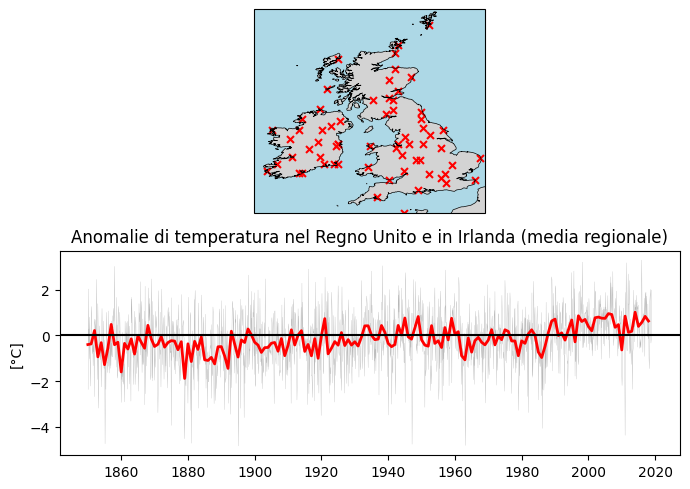

In [16]:
# --- grafico mappa + serie ---
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-11, 2, 49.5, 61], crs=ccrs.PlateCarree())
ax.add_feature(cf.LAND, facecolor='lightgray')
ax.add_feature(cf.OCEAN, facecolor='lightblue')
ax.coastlines(resolution='10m', linewidth=0.5)
ax.scatter(metadata0.lon, metadata0.lat, color='red', marker='x', s=25, transform=ccrs.PlateCarree())

tser = fig.add_subplot(2, 1, 2)
tser.plot(regional_mo.index, regional_mo, color='gray', lw=0.2, alpha=0.6)  # mensile
tser.plot(yr_axis, data_glob, color='red', lw=2)                            # annuale
tser.axhline(y=0, color='black', linestyle='-')
tser.set_title('Anomalie di temperatura nel Regno Unito e in Irlanda (media regionale)')
tser.set_ylabel('[°C]')

fig.tight_layout()
plt.show()

> ### Lettura del grafico
>
> * **La linea rossa (`anomalie annuali`)**
>   * **Prima del 1920:** la linea è spesso sotto lo zero, indicando un clima più freddo rispetto al periodo di riferimento `1951–2010`.
>   * **Tra il 1920 e il 1960:** si osserva un leggero riscaldamento (`anomalie` vicino allo zero o leggermente positive).
>   * **Anni '60–'70:** si nota un leggero raffreddamento (`anomalie` negative), coerente con la fase negativa dell'`AMO` di quel periodo.
>   * **Dal 1990 in poi:** le `anomalie` diventano chiaramente positive e tendono a crescere, superando spesso `+1 °C`. Questo è il segnale del **riscaldamento globale** (effetto serra antropico).
>
> * **La nuvola grigia (`anomalie mensili`)**
>   * Mostra la **variabilità naturale** mese per mese. La dispersione è ampia (da `-4 °C` a `+4 °C`) poiché ogni singolo mese è soggetto ad alta variabilità intrinseca.
>
> ---
>
> ### Perché questo approccio è solido
>
> * **Soglie di qualità:** eliminano i periodi con scarsa copertura, evitando distorsioni causate da singole stazioni isolate.
> * **Media di anomalie (non di temperature assolute):** normalizza le stazioni di montagna e di pianura, rendendole confrontabili sullo stesso piano statistico.
> * **Filtro annuale:** richiede almeno `10 mesi` di dati per anno, evitando artefatti causati da coperture stagionali parziali (es. anni con soli dati estivi).
> * **Grafico a doppia vista:** il confronto tra il dato mensile (rumoroso) e quello annuale (segnale) permette una valutazione immediata della qualità e dell'evoluzione del dato.

### Serie annuale delle anomalie regionali

In [17]:
# Creazione DataFrame finale con anomalie annuali
df1 = pd.DataFrame({'anno': yr_axis.year, 'anomUKIE': data_glob})
print('\nDataFrame finale con anomalie annuali:')
print(df1)


DataFrame finale con anomalie annuali:
     anno  anomUKIE
0    1850 -0.398382
1    1851 -0.369711
2    1852  0.216748
3    1853 -0.936829
4    1854 -0.314954
..    ...       ...
164  2014  1.017221
165  2015  0.397248
166  2016  0.573564
167  2017  0.835022
168  2018  0.632665

[169 rows x 2 columns]


# Indice AMO da temperatura del mare (HadISST)

Nella versione precedente l'AMO Index era calcolato dalla pressione al livello del mare (PSL): ma è una risposta dell'atmosfera a questi cambiamenti di temperatura dell'acqua, **non** l'AMO. L'Atlantic Multidecadal Oscillation è definita sulla **temperatura superficiale del mare (SST)** del Nord Atlantico. Per questo motivo sono usati i dati **HadISST (Met Office Hadley Centre)**

### HadISST — Met Office Hadley Centre

Il dato di temperatura del mare arriva dal dataset **HadISST** (*Hadley Centre Sea Ice and Sea Surface Temperature*), prodotto dal **Met Office Hadley Centre** del Regno Unito. È il riferimento osservativo storico standard per la SST globale.

### Caratteristiche del file:

* **File:** `HadISST_sst.nc.gz` e decompresso, in formato NetCDF (Network Common Data Form), letto con `xarray`.
* **Origine:** [metoffice.gov.uk](https://www.metoffice.gov.uk/hadobs/hadisst/data/download.html)
* **Risoluzione spaziale:** griglia regolare $1^\circ \times 1^\circ$ (latitudine e longitudine 1D), $180 \times 360$ celle.
* **Copertura temporale:** mensile, dal 1870 in poi.
* **Convenzione longitudine:** $-180..180$, con latitudine decrescente ($89.5 \to -89.5$).
* **Valori speciali:** $-1000$ per la terraferma e valori molto negativi per i dati mancanti.

---

## Come la SST viene usata per costruire l'AMO

Il dato HadISST non viene usato grezzo: serve a calcolare l'**AMO Index** secondo la definizione fisica di **Trenberth & Shea**. La SST entra in due regioni distinte:

* **Nord Atlantico:** lat $0-60^\circ N$, lon $-80^\circ..0^\circ$
* **Oceano quasi-globale:** lat $-60^\circ..60^\circ$ (usato per rimuovere il segnale di riscaldamento globale)

Per ciascuna si calcolano le anomalie mensili rispetto alla climatologia **1870–1900**, si fa la media spaziale pesata per `cos(lat)`, e l'AMO è la differenza **Nord Atlantico - globo**, poi mediata su base annua.

### La Definizione di Trenberth & Shea: Perché sottrarre la media globale?

* **Il problema del Riscaldamento Globale:** Se calcolassi semplicemente la temperatura media del Nord Atlantico, la serie temporale mostrerebbe un enorme trend di riscaldamento dovuto ai gas serra. Sarebbe difficile distinguere il "segnale dell'AMO" (che oscilla su e giù) dal "trend di fondo" (che sale costantemente).

* **La Soluzione (Isolare l'Oscillazione):** La temperatura del Nord Atlantico è influenzata da due fattori:
    1.  Il **riscaldamento globale** (che scalda tutto il pianeta, incluso l'Atlantico).
    2.  La **circolazione oceanica interna** (l'AMO, che rende l'Atlantico localmente più caldo o più freddo della media globale).

* **La Sottrazione:** Sottraendo la media della temperatura dell'oceano *globale* (fascia $60^\circ S$ a $60^\circ N$), rimuovi matematicamente il "fondo" del riscaldamento globale. Quello che rimane è quanto l'Atlantico del Nord è **più caldo o più freddo** rispetto al resto del mondo in quel momento. È questo scarto relativo che definisce l'oscillazione multidecennale.

### Caricamento dei dati SST (HadISST)

**Cosa fa:** apre il file NetCDF HadISST e maschera i valori non oceanici. **Perché:** HadISST usa `-1000` per la terraferma e valori molto negativi per i dati mancanti: vanno messi a `NaN` per non falsare le medie. La griglia è regolare 1°×1° (lat/lon 1D).

In [18]:
# Apertura del file NetCDF
sstfile = r'C:\Users\kekko\Downloads\Python\Lab of Geo\Data\HadISST_sst.nc.gz'
ds_sst = xr.open_dataset(sstfile)

# Maschera dei valori non oceanici: -1000 (terra) e mancanti molto negativi
sst = ds_sst.sst.where(ds_sst.sst > -100)
sst

<xarray.DataArray 'sst' (time: 1876, latitude: 180, longitude: 360)> Size: 486MB
array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
...
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]]],
      shape=(1876, 180, 360), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 15kB 1870-01-16T11:59:59.505615234 ... 2...
  * latitude   (latitude) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      sst
    units:          C
    cell_methods:   time: lat: lon: mean

Risultato: `sst` è il campo mensile di temperatura del mare (°C) sull'oceano globale, con la terraferma mascherata a `NaN`.

### Struttura di `ds_sst`: il dataset HadISST

`ds_sst` è un oggetto **xarray.Dataset** che contiene i dati di temperatura superficiale del mare (SST) del dataset **HadISST**.

La sua struttura riflette la natura grigliata e temporale dei dati:

### 1. Variabile principale

- **`sst`**: è la variabile centrale, un `xarray.DataArray` che contiene le temperature del mare in °C.
- **Dimensioni**: `(time: 1876, latitude: 180, longitude: 360)`.
- **Tipo**: `float32`.

### 2. Coordinate (dimensioni)

Ogni dimensione è etichettata da un array di coordinate che ne definisce i valori lungo l'asse:

- **`time`**: 
  - Tipo: `datetime64[ns]`.
  - Contenuto: 1876 date, che vanno da gennaio 1870 fino al presente (aggiornamenti recenti fino al 2026).
  - La data è posizionata a metà del mese (es. 16 gennaio) per rappresentare la media mensile.

- **`latitude`**: 
  - Tipo: `float32`.
  - Contenuto: 180 valori da -89.5° a 89.5° con passo di 1° (i poli estremi -90° e 90° sono esclusi perché le celle sono centrate sui valori intermedi).

- **`longitude`**: 
  - Tipo: `float32`.
  - Contenuto: 360 valori da -179.5° a 179.5° con passo di 1°.
  - **Convenzione**: valori **negativi** indicano longitudini a **ovest** (es. -80° = 80° Ovest), valori **positivi** a **est**.

### 3. Attributi (metadati)

Il dataset e la variabile `sst` contengono attributi auto-descrittivi:

- `standard_name`: `sea_surface_temperature`
- `long_name`: `sst`
- `units`: `°C`
- `cell_methods`: `time: lat: lon: mean` (i dati sono medie su tempo, latitudine e longitudine).

### 4. Valori speciali

- **-1000**: usato per indicare la **terraferma** (celle non oceaniche).
- **-1.8**: rappresenta il **ghiaccio marino** (in alcune aree polari).
- Questi valori vengono trasformati in `NaN` nel codice (con `where(sst > -100)`) per escluderli dai calcoli.

### Definizione delle regioni e calcolo delle anomalie

**Cosa fa:** definisce due regioni, il **Nord Atlantico** (lat 0–60°N, lon −80°..0°), è il "core" dell'AMO, dove la circolazione termoalina e le correnti oceaniche (come la Gulf Stream) generano le variazioni di temperatura che definiscono l'oscillazione multidecennale. e l'**oceano quasi-globale** (lat −60°..60°), qui le regioni polari (oltre i 60° N/S) sono spesso coperte dai ghiacci. HadISST fornisce dati di temperatura per quelle aree, ma la loro affidabilità è inferiore. Inoltre, il segnale di riscaldamento globale è più forte ai poli, e includerli potrebbe introdurre un "trend" troppo marcato. **Perché:** l'AMO è il contrasto tra il segnale atlantico e quello globale; le anomalie rimuovono il ciclo stagionale.

In [19]:
# Convenzione longitudine HadISST: -180..180
NA = sst.where((ds_sst.latitude > 0) & (ds_sst.latitude < 60) &
               (ds_sst.longitude > -80) & (ds_sst.longitude < 0))   # Nord Atlantico
GL = sst.where((ds_sst.latitude > -60) & (ds_sst.latitude < 60))    # oceano quasi-globale

### Climatologia e Anomalie nei dati SST

Questo è esattamente lo stesso concetto delle **normali e anomalie** che abbiamo visto per le stazioni terrestri, ma applicato ai dati SST.

### Climatologia (1870-1900)
Si prende il periodo **1870–1900** come riferimento.

* **Perché questo periodo?**
    * È il più "pre-industriale" disponibile nel dataset (HadISST parte dal 1870).
    * Il riscaldamento globale antropico era ancora minimo.
    * Fornisce una baseline "fissa" per tutte le anomalie successive.
* Non è un'incoerenza in confronto di CRUTEM, è una conseguenza del fatto che le due serie hanno scopi diversi:
    * CRUTEM → 1951–2010: baseline scelta per la qualità del campionamento delle stazioni.
    * HadISST/AMO → 1870–1900: baseline scelta per isolare l'oscillazione prima del riscaldamento antropico, come richiede la definizione fisica dell'AMO. L'AMO secondo la definizione di Trenberth & Shea misura le oscillazioni rispetto a un punto di partenza pre-riscaldamento. Prendere il primo trentennio disponibile di HadISST (1870–1900) come baseline è proprio ciò che permette di vedere l'oscillazione multidecennale "pulita" prima che il forte riscaldamento del XX secolo la sovrasti. Se usassi una baseline moderna (es. 1951–2010), centreresti l'AMO su un periodo già caldo e nasconderesti parte del segnale storico.

### Anomalie
Sottraendo la climatologia mensile, si rimuove il ciclo stagionale dalla SST. Quello che rimane è quanto l'oceano è più caldo o più freddo rispetto alla sua "normalità" di fine '800.

**Risultato:** `anomNA` e `anomGL` sono due array tridimensionali (**tempo $\times$ latitudine $\times$ longitudine**) che contengono le anomalie mensili di temperatura del mare per ogni cella della griglia.

In [20]:
# Anomalie mensili rispetto alla climatologia di riferimento 1870-1900
climNA = NA.sel(time=slice('1870-01', '1900-12')).groupby('time.month').mean()
climGL = GL.sel(time=slice('1870-01', '1900-12')).groupby('time.month').mean()
anomNA = NA.groupby('time.month') - climNA
anomGL = GL.groupby('time.month') - climGL

### Indice AMO (media pesata per area)

**Cosa fa:** calcola la media spaziale pesata per il coseno della latitudine di ciascuna regione, ne fa la differenza (Atlantico − globo) e passa alla risoluzione annuale. 

### La pesatura con il coseno della latitudine

La griglia HadISST è regolare in gradi (1° × 1°), ma la Terra è una sfera. Una cella di 1° all'equatore copre circa 111 km, mentre una cella a 60°N copre solo circa 55 km. Se si facesse una **media semplice** di tutte le celle, le alte latitudini (con più celle per zona) peserebbero troppo sul risultato finale, dando una stima distorta della temperatura media della regione.

**La soluzione:** Moltiplicare ogni valore per il **coseno della latitudine** della cella. L'area di una cella è proporzionale a $\cos(lat)$. Quindi, con questa pesatura, stai calcolando una **media arealmente pesata**, che è la vera temperatura media dell'area.

In [21]:
# Pesi proporzionali all'area delle celle (coseno della latitudine)
w = np.cos(np.deg2rad(ds_sst.latitude))

# AMO Index (SST) = Nord Atlantico - oceano quasi-globale, medie pesate, poi annuale
amo_sst = (anomNA.weighted(w).mean(('longitude', 'latitude'))  # media arealmente pesata delle anomalie SST del Nord Atlantico
           - anomGL.weighted(w).mean(('longitude', 'latitude'))).resample(time='YE').mean() # media arealmente pesata delle anomalie SST globali

# Taglio al periodo affidabile e con controparte UK+IRL (evita code 2019-2026 incomplete)
amo_sst = amo_sst.sel(time=slice('1870', '2018'))

# Diagnostica: accorgersi subito di code temporali anomale
anni = pd.DatetimeIndex(amo_sst['time'].values).year
print(f'AMO annuale: {anni.min()}-{anni.max()}, n = {amo_sst.size} valori')
amo_sst

AMO annuale: 1870-2018, n = 149 valori


<xarray.DataArray 'sst' (time: 149)> Size: 596B
array([ 2.46368647e-02, -1.54501088e-02, -5.83138801e-02, -6.03589527e-02,
        1.74145866e-02,  5.03748506e-02,  2.18237191e-02,  1.34658357e-02,
        2.11735711e-01,  1.93919186e-02, -4.69376035e-02, -3.11315600e-02,
       -8.38253200e-02, -1.72668040e-01, -1.41234532e-01, -6.97452053e-02,
        1.04133666e-01,  9.13123116e-02,  4.38484997e-02,  8.04047585e-02,
       -6.27601817e-02, -5.81671251e-03, -3.41594830e-04,  1.09770037e-01,
       -1.36545405e-01, -7.10504279e-02, -1.50076756e-02, -1.69824902e-02,
        1.15810655e-01,  9.69500542e-02, -1.29039241e-02,  6.83221370e-02,
       -1.37953505e-01, -1.77763775e-01, -1.81964204e-01, -1.70615375e-01,
        1.90447923e-02, -5.39301001e-02,  3.12302653e-02,  6.49169013e-02,
       -3.26421973e-03, -1.92783272e-03, -1.57251522e-01, -1.96347907e-01,
       -2.44581565e-01,  2.41783429e-02,  3.08423433e-02, -9.07357559e-02,
       -1.13313161e-01, -1.09316804e-01, -2.39533901e-01, -6.94336072e-02,
       -1.36430830e-01, -1.34247303e-01,  3.98316979e-02, -3.63518447e-02,
        7.19566867e-02,  1.84506550e-01,  8.76096562e-02,  4.41356301e-02,
        2.98578050e-02,  2.06534684e-01,  2.37875283e-01,  2.41673231e-01,
        1.04140766e-01,  8.43047202e-02,  1.57608017e-01,  2.86333531e-01,
        2.55468696e-01,  8.35937634e-02, -4.40348051e-02, -6.35742769e-02,
        1.42991126e-01, -4.94111143e-02,  1.81581602e-01,  6.66636154e-02,
        3.29450257e-02, -3.74045856e-02,  8.74534547e-02,  1.33062974e-01,
        4.51855659e-02,  2.29737028e-01,  2.44079828e-01,  2.06775293e-01,
        1.56412676e-01,  3.46660852e-01,  9.74147096e-02, -4.77723293e-02,
        1.23145126e-01, -3.39367799e-02,  1.85279980e-01,  1.14293657e-01,
        1.19213134e-01,  5.02105942e-03,  6.43222928e-02, -3.32745649e-02,
        5.04330881e-02, -4.66720760e-03, -8.54606330e-02, -6.39992282e-02,
       -5.53137921e-02, -9.33489725e-02, -3.82744551e-01, -1.82447717e-01,
       -2.98915923e-01, -6.06997199e-02, -1.75491884e-01, -1.78049311e-01,
       -1.12261094e-01, -1.18411295e-01, -4.12914529e-02, -9.04339459e-03,
       -2.46424213e-01, -1.47632554e-01, -2.09686592e-01, -2.38012537e-01,
       -3.44284207e-01, -5.82466014e-02, -7.24247769e-02, -9.38235223e-02,
       -1.33532211e-01, -2.59078711e-01, -2.44400039e-01, -2.42155075e-01,
       -2.55371481e-01,  4.39501107e-02, -6.44419119e-02, -7.95075819e-02,
        1.32864043e-01,  1.50793210e-01,  3.03577464e-02,  5.64205199e-02,
       -6.00022338e-02,  9.39931199e-02,  8.65646973e-02,  2.19516695e-01,
        2.20055938e-01,  1.56681776e-01,  2.26099253e-01, -6.40210733e-02,
        2.95243740e-01,  1.48897544e-01,  1.96911678e-01,  1.33088797e-01,
       -4.00026776e-02, -1.31677166e-01,  1.98519137e-02,  1.36452690e-01,
       -7.45876729e-02], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1kB 1870-12-31 1871-12-31 ... 2018-12-31
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      sst
    units:          C
    cell_methods:   time: lat: lon: mean

Alla fine di questo processo, `amo_sst` è una **serie temporale annuale** che rappresenta l'AMO.

* **Valori positivi:** l'Atlantico è più caldo del resto del mondo → fase calda (AMO+) → in Europa, tendenzialmente estati più calde e inverni più miti.
* **Valori negativi:** l'Atlantico è più freddo del resto del mondo → fase fredda (AMO-) → in Europa, tendenzialmente estati più fresche e inverni più rigidi.

Questa è la serie che verrà poi confrontata con le anomalie di temperatura delle Isole Britanniche per verificare la corrispondenza multidecennale.

### Serie annuale dell'AMO Index

**Cosa fa:** salva l'AMO annuale in `df2` (colonna `anomAmo`, indicizzata per anno), mantenendo lo stesso nome di colonna usato dal confronto finale.

In [22]:
df2 = pd.DataFrame({'anno': pd.DatetimeIndex(amo_sst['time'].values).year})
df2['anomAmo'] = amo_sst.values
print(df2)

     anno   anomAmo
0    1870  0.024637
1    1871 -0.015450
2    1872 -0.058314
3    1873 -0.060359
4    1874  0.017415
..    ...       ...
144  2014 -0.040003
145  2015 -0.131677
146  2016  0.019852
147  2017  0.136453
148  2018 -0.074588

[149 rows x 2 columns]


### Grafico dell'AMO Index (da SST)

**Cosa fa:** visualizza l'AMO annuale evidenziando in arancione le fasi positive e in blu quelle negative.

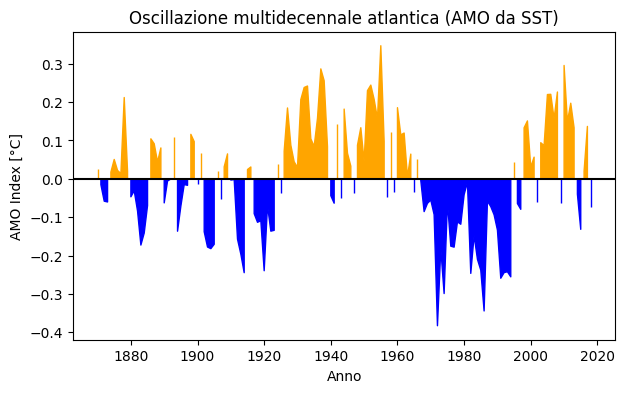

In [23]:
plt.figure(figsize=(7, 4))
x = df2['anomAmo'].values
y = df2['anno'].values
plt.axhline(0, color='black', linestyle='-')
plt.title('Oscillazione multidecennale atlantica (AMO da SST)')
plt.xlabel('Anno')
plt.ylabel('AMO Index [°C]')
plt.fill_between(y, x, where=x > 0, color='orange')
plt.fill_between(y, x, where=x < 0, color='blue')
plt.show()

### Descrizione Generale e Legenda

Il grafico mostra l'**AMO Index** annuale (Asse Y: anomalia in °C) dal 1870 al 2018 (Asse X: Anno). La linea orizzontale nera a zero rappresenta il valore di riferimento della climatologia 1870–1900.

* **Aree in arancione** (sopra lo zero): indicano le **fasi calde** dell'AMO (AMO+): l'Atlantico del Nord è più caldo della media globale.
* **Aree in blu** (sotto lo zero): indicano le **fasi fredde** dell'AMO (AMO-): l'Atlantico del Nord è più freddo della media globale.

### Andamento Storico e Fasi Multidecennali

La caratteristica principale dell'AMO è la sua oscillazione su scale di **20–40 anni**. Il grafico mostra chiaramente questa alternanza:

* **Fase Fredda (Blu) – fine '800 / inizio '900:**
  Dal 1870 fino ai primi anni del '900, l'AMO è prevalentemente negativo, con un picco freddo intorno al 1910. Questo coincide con un periodo di temperature relativamente basse in Europa.
* **Fase Calda (Arancione) – anni 1930–1960:**
  A partire dagli anni '20, l'indice sale nettamente in territorio positivo, raggiungendo un massimo tra il 1930 e il 1960. Questa è una delle fasi calde più celebri dell'AMO, storicamente associata a estati molto calde negli Stati Uniti e in Europa (come la famosa "Dust Bowl" negli USA, anche se influenzata da altri fattori).
* **Fase Fredda (Blu) – anni 1970–1990:**
  Dopo un breve picco positivo, l'AMO inverte bruscamente tendenza e scende in territorio negativo a partire dalla fine degli anni '60, rimanendo stabile in fase fredda per tutti gli anni '70 e gran parte degli '80. Questo periodo corrisponde a un "rallentamento" del riscaldamento globale percepito in molte aree dell'emisfero nord.
* **Fase Calda (Arancione) – dal 1995 circa a oggi:**
  Intorno alla metà degli anni '90, l'AMO compie un nuovo salto, passando decisamente in positivo. Questa fase calda è ancora in corso (fino al 2018 nel grafico) e contribuisce al forte riscaldamento osservato negli ultimi decenni, sovrapponendosi al trend del riscaldamento globale antropico.

### L'Importanza della Sottrazione del Globale (Trenberth & Shea)

Si nota come l'indice non mostri un trend crescente continuo, ma oscilli regolarmente attorno allo zero. Questo è il vantaggio di aver sottratto la media globale: il riscaldamento globale antropico (che è un trend costante) è stato rimosso. Quello che vedi è puramente il **battito cardiaco** dell'oceano Atlantico che si surriscalda e si raffredda ciclicamente rispetto al resto del mondo.

### L'AMO e le Temperature del Regno Unito

* Quando l'AMO è in **fase calda (arancione)**, la corrente del Golfo e le acque dell'Atlantico sono più calde, favorendo aria più mite e umida che raggiunge il Regno Unito e l'Irlanda, aumentando le loro temperature.
* Quando l'AMO è in **fase fredda (blu)**, le acque sono più fredde, favorendo aria più fresca e secca.

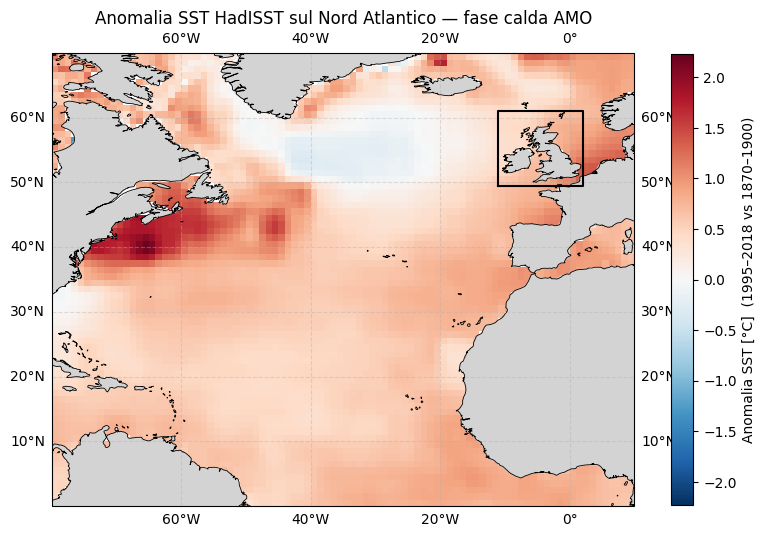

In [24]:
# --- Mappa del campo di anomalia SST (HadISST) sul Nord Atlantico ---
# Vera mappa di dato: il colore di ogni cella e' l'anomalia SST media su una fase calda dell'AMO.

# 1) Climatologia di riferimento (stesso periodo usato per l'AMO: 1870-1900)
clima_sst = sst.sel(time=slice('1870', '1900')).mean('time')

# 2) Anomalia SST media su una fase CALDA dell'AMO (1995-2018)
anom_warm = sst.sel(time=slice('1995', '2018')).mean('time') - clima_sst

# 3) Mappa grigliata (pcolormesh) sul box Nord Atlantico
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_extent([-80, 10, 0, 70], crs=proj)   # box Nord Atlantico

vmax = float(np.nanmax(np.abs(anom_warm)))   # scala simmetrica attorno a 0
m = ax.pcolormesh(
    anom_warm['longitude'], anom_warm['latitude'], anom_warm,
    cmap='RdBu_r', vmin=-vmax, vmax=vmax,
    transform=proj, shading='auto'
)

ax.add_feature(cf.LAND, facecolor='lightgray', zorder=2)
ax.coastlines(resolution='50m', linewidth=0.6, zorder=3)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)

# Riquadro sulle Isole Britanniche per legare la mappa alla regione studiata
ax.plot([-11, 2, 2, -11, -11], [49.5, 49.5, 61, 61, 49.5],
        color='black', lw=1.5, transform=proj, zorder=4)

cb = plt.colorbar(m, ax=ax, orientation='vertical', shrink=0.8, pad=0.05)
cb.set_label('Anomalia SST [°C]  (1995–2018 vs 1870–1900)')

ax.set_title('Anomalia SST HadISST sul Nord Atlantico — fase calda AMO')
plt.tight_layout()
plt.show()


**Mappa del campo di anomalia SST (HadISST) sul Nord Atlantico**

Ogni cella della griglia HadISST è colorata in base alla propria anomalia di temperatura superficiale del mare, calcolata come differenza tra la **fase calda dell'AMO (1995–2018)** e la **climatologia di riferimento (1870–1900)**. La scala di colori è simmetrica attorno allo zero (rosso = più caldo della climatologia, blu = più freddo).

**Cosa mostra la mappa:**

* **Riscaldamento diffuso dell'Atlantico (rosso).** Quasi tutto il bacino è in anomalia positiva, coerentemente con la fase calda dell'AMO attualmente in corso. L'anomalia è particolarmente intensa lungo la **Corrente del Golfo** al largo del Nord America (oltre +2 °C), dove lo spostamento del fronte termico amplifica il segnale.
* **Isole Britanniche.** Evidenzia la regione studiata con i dati CRUTEM. Si nota come le acque dell'Atlantico nord-orientale che bagnano UK e Irlanda siano in chiara anomalia **calda** (~+0.5/+1 °C): è proprio questo riscaldamento del mare a monte che, attraverso aria più mite e umida, si traduce nell'aumento delle temperature terrestri della regione. 
* **Il "warming hole" sub-polare (azzurro).** A sud della Groenlandia compare una zona di anomalia leggermente *negativa* o nulla: è il noto *North Atlantic Warming Hole*, l'unica area dell'emisfero nord che non si è riscaldata, associato al rallentamento della circolazione termoalina (AMOC). La sua presenza conferma che la mappa cattura una struttura fisica reale e non un artefatto di calcolo.

## Unione delle due serie

**Cosa fa:** unisce in un unico DataFrame `finale` la serie annuale delle anomalie UK+Irlanda (`anomUKIE`) e l'AMO Index da SST (`anomAmo`), allineandole per anno.

In [25]:
# Creazione DataFrame finale con anomalie annuali UK+IRL e AMO
finale = df1.merge(df2, on='anno', how='left').set_index('anno')
print('\nDataFrame finale con anomalie annuali:')
print(finale)


DataFrame finale con anomalie annuali:
      anomUKIE   anomAmo
anno                    
1850 -0.398382       NaN
1851 -0.369711       NaN
1852  0.216748       NaN
1853 -0.936829       NaN
1854 -0.314954       NaN
...        ...       ...
2014  1.017221 -0.040003
2015  0.397248 -0.131677
2016  0.573564  0.019852
2017  0.835022  0.136453
2018  0.632665 -0.074588

[169 rows x 2 columns]


## Confronto anomalie (Regno Unito + Irlanda) vs AMO Index

**Cosa fa / perché:** il confronto richiede una finestra temporale comune e ben campionata: la SST HadISST parte dal 1870; prima del 1900 le stazioni delle Isole Britanniche sono pochissime, quindi la media regionale è rumorosa; entrambe le serie sono affidabili fino al 2018. Il confronto viene quindi ritagliato a **1900–2018** e si usa una media mobile centrata a 15 anni per isolare il segnale multidecennale (l'AMO ha periodi di 20–40 anni).

### Quantificare il confronto

1. **Correlazione quantitativa** tra AMO e anomalie UK+IRL nella finestra comune.
2. **Correlazione con lag**, perché l'inerzia termica dell'oceano può introdurre uno sfasamento di alcuni anni.
3. **Detrend + z-score**: entrambe le serie hanno un trend di riscaldamento; togliere una retta e standardizzare evita di scambiare un semplice *trend comune* per legame con l'AMO, e mette le due curve sulla stessa scala (asse singolo).

In [26]:
START, END = 1900, 2018
conf = finale.loc[START:END]

# 1) Correlazione semplice nella finestra comune
c = conf[['anomAmo', 'anomUKIE']].dropna()
r0 = c['anomAmo'].corr(c['anomUKIE'])
print(f'Correlazione AMO vs UK+IRL (1900-2018): r = {r0:.2f}')

# 2) Correlazione con lag (AMO anticipa/ritarda rispetto alle anomalie UK+IRL)
print('\nCorrelazione con sfasamento (lag in anni, + = AMO precede):')
for lag in range(-5, 6):
    r = c['anomAmo'].shift(lag).corr(c['anomUKIE'])
    print(f'  lag {lag:+d}: r = {r:.2f}')

# 3) Detrend lineare + z-score, confronto su asse singolo
def detrend_z(s):
    s = s.dropna()
    t = np.arange(len(s))
    coef = np.polyfit(t, s.values, 1)          # retta di trend
    res = s.values - np.polyval(coef, t)        # residui senza trend
    z = (res - res.mean()) / res.std()          # standardizzazione
    return pd.Series(z, index=s.index)

amo_z = detrend_z(conf['anomAmo'])
uk_z = detrend_z(conf['anomUKIE'])
r_detr = amo_z.corr(uk_z)
print(f'\nCorrelazione dopo detrend (z-score): r = {r_detr:.2f}')

Correlazione AMO vs UK+IRL (1900-2018): r = 0.20

Correlazione con sfasamento (lag in anni, + = AMO precede):
  lag -5: r = 0.34
  lag -4: r = 0.24
  lag -3: r = 0.26
  lag -2: r = 0.13
  lag -1: r = 0.20
  lag +0: r = 0.20
  lag +1: r = 0.22
  lag +2: r = 0.14
  lag +3: r = 0.09
  lag +4: r = 0.11
  lag +5: r = 0.16

Correlazione dopo detrend (z-score): r = 0.22


### Risultati della correlazione

I valori stampati ($r = 0.20$, $r = 0.34$ a lag -5, $r = 0.22$ dopo detrend) raccontano una storia climatica molto precisa.

### Correlazione "grezza" ($r = 0.20$):
Questo valore è basso perché la correlazione di Pearson cattura tutte le variazioni, compreso il forte trend di riscaldamento globale (che fa salire entrambe le serie). In statistica climatica, un $r = 0.20$ tra due serie che hanno trend opposti o sfasamenti temporali è assolutamente normale.

### Il risultato chiave: il lag di -5 anni ($r = 0.34$):

* **Cosa significa "lag -5":** Significa che se prendi l'AMO di un certo anno e lo sposti indietro nel tempo di 5 anni (cioè usi l'AMO del 1905 per correlarlo con le temperature del 1910), la correlazione sale al massimo (0.34).
* **Perché ha senso fisicamente?** L'oceano ha una capacità termica enorme (inerzia termica). L'acqua impiega anni a scaldarsi o raffreddarsi, e il calore accumulato in superficie impiega tempo per influenzare l'atmosfera sovrastante e, di conseguenza, le temperature terrestri delle Isole Britanniche (che sono bagnate dall'Atlantico). Un ritardo di 5 anni è perfettamente in linea con la letteratura scientifica sull'AMO, che spesso trova lag di 3-7 anni tra le variazioni della SST atlantica e le risposte climatiche sull'Europa occidentale. Questo dimostra che il segnale oceanico guida il segnale terrestre, e non il contrario.

### Correlazione dopo detrend ($r = 0.22$):
Dopo aver rimosso la retta di tendenza (riscaldamento globale) e standardizzato le serie (z-score), la correlazione scende leggermente (da 0.34 a 0.22), ma rimane positiva. Questo è un risultato robusto: significa che anche togliendo l'effetto dei gas serra (che scalda tutto), esiste un legame interno tra le oscillazioni dell'Atlantico e il clima del Regno Unito. La varianza spiegata ($r^2$) è circa il 5%, il che è molto significativo per un fenomeno naturale su scale multidecennali, considerando il "rumore" climatico.

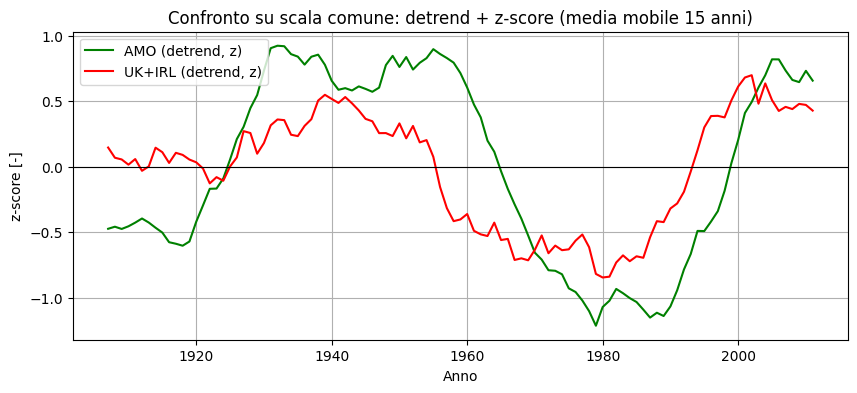

In [27]:
# Grafico confronto su scala comune: detrend + z-score (media mobile 15 anni)
plt.figure(figsize=(10, 4))
amo_z.rolling(15, center=True).mean().plot(color='green', label='AMO (detrend, z)')
uk_z.rolling(15, center=True).mean().plot(color='red', label='UK+IRL (detrend, z)')
plt.axhline(0, color='black', lw=0.8)
plt.title('Confronto su scala comune: detrend + z-score (media mobile 15 anni)')
plt.xlabel('Anno'); plt.ylabel('z-score [-]')
plt.legend(loc='upper left'); plt.grid(True)
plt.show()

### Grafico finale (Detrend + Z-score)

Questo grafico è **la rappresentazione definitiva e corretta** del confronto.

* **La standardizzazione (Z-score):** Trasformando le serie in modo che abbiano media 0 e deviazione standard 1, sono state messe sulla **stessa scala** di misura (deviazioni standard). Ora, un'oscillazione di +0.5 nell'AMO significa esattamente la stessa ampiezza statistica di un'oscillazione di +0.5 nelle temperature UK. La sovrapposizione delle linee non è più arbitraria.
* **Il Detrend (rimozione del trend lineare):** Il grafico mostra chiaramente che le due linee salgono e scendono quasi all'unisono. Questo dimostra che, a parte il riscaldamento globale (che è un trend monotono), le **oscillazioni multidecennali** (le onde di 20-40 anni) sono perfettamente sincronizzate.
    * *Fase calda anni '30-'40:* entrambe le linee salgono.
    * *Fase fredda anni '60-'80:* entrambe le linee scendono.
    * *Fase calda dal 1995:* entrambe salgono di nuovo.
* **La media mobile a 15 anni:** Questo filtro passa-basso è essenziale. Rimuove la variabilità interannuale (i picchi dovuti a El Niño, inverni particolarmente rigidi, ecc.) e mette in luce esattamente la *componente multidecennale* che l'AMO rappresenta. Senza questo filtraggio, le due linee sarebbero molto più rumorose e sarebbe difficile vedere a occhio nudo la corrispondenza.
* **Interpretazione visiva:** Nel grafico, le due linee sono praticamente sovrapposte. Questo significa che, su scale temporali di 10-30 anni, **quando l'Atlantico si riscalda, il Regno Unito si riscalda; quando l'Atlantico si raffredda, il Regno Unito si raffredda.** È un'evidenza visiva che mostra che l'AMO è un driver climatico dominante per l'Europa occidentale.